2023 Updates:
1) In your file name, you can now specify cells and subcellular regions if you are analyzing multiple neurons and regions of the same neuron. For instance, on a given slide I will often have AFD:GCaMP and AIY:GCaMP animals, and within AFD I want to analyze both the soma and axon. In ImageJ/Fiji I will generate separate GCaMP/RFP files for each neuron / subcellular compartment. I will name the files via the following syntax:
RepName_CellName_SubcellName_Results.csv
For instance, instead of 
051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1_Results.csv
I'll have
051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1_AFD_Results.csv
or
051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1_AFD_Axon_Results.csv.

Note: the code does not *require* these additions, just allows for them. If you specify that the cell is AFD or AIY, the code will authomatically calculate AIY responses/response rate and AFD onset temperatures.
The subcellular name can be anything.

The way these names are called is when load_GCaMP_RFP_meta_stim is called, cell and subcell are kwargs that can take input names (default is 'None'), below are examples of how this function is called (right) for a given results file name (left):
051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1_Results.csv    -->    load_GCaMP_RFP_meta_stim(Meta, Stim)
I'll have
051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1_AFD_Results.csv    -->    load_GCaMP_RFP_meta_stim(Meta, Stim, cell='AFD')
or
051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1_AFD_Axon_Results.csv    -->    load_GCaMP_RFP_meta_stim(Meta, Stim, cell='AFD', subcell = 'Axon')

2) Heatmaps are now ordered from the replicate with the strongest max delta F/F or R/R signal to the weakest.

3) Heatmaps in the same figure are guaranteed to be on the same scale, ranging from the max across all heatmaps to the min across all heatmaps. If this ever is not appropriate for your data, where imshow is called vmax and vmin can be hardcoded to other numbers rather than the min/max across the dataset.

4) Turned plotting into a function - this will make it more restricted but hopefully more ready to use out of the box.
Options in plotting function are: 
separate_temp: default is False, making True will plot temp stimulus and average delta R/R values on two separate plots
start_ind/stop_ind: can set as an index number, default is min=0/max=length of first condition plotted
colorbar: default is False, true would plot a colorbar next to the heatmaps (good for checking but takes up space and misaligns heatmaps from average plots)
sort: default is True, changing to false will make heatmaps no longer sorted by row max

5) Time is in seconds instead of miliseconds.


Original markdown:
This script assumes you have at least a GCaMP and metadata file in the same folder with the following naming convention:
GCaMP file = 'Replicate_name_Results.csv'
Metadata file = 'Replicate_name_MMStack_Pos0_metadata.txt'

You may also have an RFP results file with the following name:
RFP file = 'Replicate_name_Results_RFP.csv'

For each replicate you must also have a stim file with the auto-generated name of 'Start_time.txt'

For each condition you which to analyze, create a list of corresponding replicate names and stim file names. For example,
see below for the Min0 condition examples:
Min0_meta = ['051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1', '051121_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1']
Min0_stim = ['051021_171757_216', '051121_214436_704']

If these files are in a different directory from the code, specify the directory name like 'input_directory/Replicate_name'
or 'input_directory/stim_name' in each list.

The function 'load_GCaMP_RFP_meta_stim' will load in your data, align it to the temperature stimulus, and calculate the
metrics below. 

The input to load_GCaMP_RFP_meta_stim are 1) the list of replicate names, 2) the list of stimulus names,
3) the cell type (AFD or AIY) as a string (different parameters are calculated for the two cell types), 4) RFP_check = False
must be provided as an input to this function if there is NO corresponding Results_RFP.csv file.

Calling this function for our Min0 example:
Min0 = load_GCaMP_RFP_meta_stim(Min0_meta, Min0_stim, 'AFD')
If there was no RFP file we would specify:
Min0 = load_GCaMP_RFP_meta_stim(Min0_meta, Min0_stim, 'AFD', RFP_check = False)

Each metric is stored as an array (GCaMP, RFP, Scaled, Delta) or a list (Mean, Std_high, Std_low, Mean_Delta,
Std_high_Delta, Std_low_Delta, Time, Temp). Each column in the array/list corresponds to a 1/10th of a second interval from the
temperature stimulus. Each row in the arrays corresponds to an ROI/neuron/row from your initial results file. All of the metrics
are stored in one dictionary with the condition name (e.g. Min0), and the dictionary keys are the metric names. For example,
Min0['GCaMP'] returns the array of GCaMP values where each column is a 1/10th second time point and each row is an ROI/neuron/
row from your initial results file. 

Below are listed all of the metrics calculated for both AFD and AIY
GCaMP: Array of GCaMP values.
RFP: Array of RFP values.
Scaled: For each time point the GCaMP/RFP ratio is calculated, then the ratios for each ROI are min-max scaled on a range from 0
    to 1.
Delta: The GCaMP/RFP ratios for each frame are normalized by subtracting the min ratio from each then dividing by the min ratio.
Mean: The average min-max scaled ratio for each timepoint.
Std_high: One standard deviation above the average min-max scaled ratio for each timepoint.
Std_low: One standard deviation below the average min-max scaled ratio for each timepoint.
Mean_Delta: The average delta F / F ratio for each timepoint.
Std_high_Delta: One standard deviation above the average delta F / F ratio for each timepoint.
Std_low_Delta: One standard deviation below the average delta F / F ratio for each timepoint.
Time: The time passed from the start of the stimulus for each timepoint.
Temp: The temperature at each timepoint.

Below are listed all the metrics calculated for just AFD:
Deriv: Instantaneous derivative of the average min-max scaled ratio for each timepoint (list).
Response_frame: Initial frame (after the start point, default one min) when the AFD deriv crosses the specified threshold. The start point and 
    threshold are specified in the function 'find_AFD_deriv_and_response_thresh' and can be altered.
Response_temp: Temperature experienced at the point of the response_frame.

Below are listed all the metrics calculated for just AIY:
Resp: Array of zeroes, except values set to 1 at the timepoints where the AIY scaled ratio derivatives cross the specified
    threshold (which can be changed in the function 'calc_AIY_responses')
Resp_Rate: The frequency with which each AIY responds per specified time period (which can be changed in the same function,
    default is one minute)
Mean_Resp_Rate: The average resp_rate across all AIYs.

To save any figure generated you can right click and save figure, or utilize plt.savefig()
Matplotlib pyplot is used to plot all figures here, for troubleshooting can google matplotlib functionalities.
The simple command plt.plot(x_values,y_values) will produce a plot, all other lines for each plot are adding features,
improving appearance.

Feel free to each out to me (Jon) with questions!!

'''

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
sns.set_style("white")
sns.set_style("ticks") 
from scipy.stats import sem
from scipy.stats import tstd
from sklearn.preprocessing import minmax_scale
from matplotlib.pyplot import cm

import json

from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

mpl.rcParams['image.interpolation']='none'

In [2]:
def extract_frameTimes_from_metadata(metadata_filename):
    frameTimes = []
    
    with open(metadata_filename) as f:
        metadata = json.load(f)
    f.close()
    
    if int(metadata['Summary']['MicroManagerVersion'][0]) == 1:
        print('MicroManager v1')
        hour = int(metadata['FrameKey-0-0-0']['Time'][11:13])
        minute = int(metadata['FrameKey-0-0-0']['Time'][14:16])
        second = int(metadata['FrameKey-0-0-0']['Time'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)-int(metadata['FrameKey-0-0-0']['ElapsedTime-ms'])
    elif int(metadata['Summary']['MicroManagerVersion'][0]) > 1:
        print('MicroManager v2 or greater')
        hour = int(metadata['Summary']['StartTime'][11:13])
        minute = int(metadata['Summary']['StartTime'][14:16])
        second = int(metadata['Summary']['StartTime'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+int(metadata['Summary']['StartTime'][20:23])

    for i in range(len(metadata.keys())-1):
        frame_name = "FrameKey-"+str(i)+"-0-0"
        #print(frame_name, start_time + int(metadata[frame_name]['ElapsedTime-ms']))
        frameTimes.append(start_time + int(metadata[frame_name]['ElapsedTime-ms']))
            
    return frameTimes

def extract_temps_times_from_metadata(stim_filename):
    Stim_data = {}
    Stim_data['Temp'] = []
    Stim_data['Time'] = []
    with open(stim_filename, "r") as stim:
        if '/' in stim_filename:
            stim_filename = stim_filename.split('/')[-1]
            
        rep_to_time = stim_filename.split(".txt")[0].split("_")
        hour = int(rep_to_time[1][0]+rep_to_time[1][1])
        minute = int(rep_to_time[1][2]+rep_to_time[1][3])
        #second = int(rep_to_time[1][4]+rep_to_time[1][5])
        #ms = int(rep_to_time[2])
        #starting_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
        hour_min = (hour*60*60*1000)+(minute*60*1000)

        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            #print(line
            pieces = line.split("\t")
            if len(pieces) < 2 or len(pieces) > 4:
                continue
            else:
                Stim_data['Temp'].append(float(pieces[0]))

                sec = int(pieces[3].split(".")[0])
                ms = int(pieces[3].split(".")[1])
                elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                
                if (hour_min+elapsed_time) >= 86400000:
                    midnight_crossing = hour_min+elapsed_time
                    elapsed_time = midnight_crossing - 86400000
                    elapsed_time_check = -1
                    hour_min = 0
                    elapsed_min = 0

                if elapsed_time > elapsed_time_check:
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                elif elapsed_time <= elapsed_time_check:
                    elapsed_min += 1
                    elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                else:
                    print('issue, something wrong')
    stim.close()
    return Stim_data

def align_Ca_to_stim(GCaMP_array, RFP_array, frameTimes, Stim):
    Stim_aligned_data = {}
    Stim_aligned_data['GCaMP'] = np.zeros((len(GCaMP_array),len(Stim['Time'])))
    Stim_aligned_data['RFP'] = np.zeros((len(RFP_array),len(Stim['Time'])))
    Stim_aligned_data['Time'] = []
    Stim_aligned_data['Temp'] = Stim['Temp']
    check = 1
    midnight_checker = 0
    for i in range(len(Stim['Time'])):
        if Stim['Time'][i-1] > 86340000 and Stim['Time'][i] < 60000 and midnight_checker == 0:
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
            midnight_checker = 1
        elif midnight_checker == 1: 
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
        else:
            Stim_aligned_data['Time'].append(Stim['Time'][i]-Stim['Time'][0])
        if Stim['Time'][i] > max(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,(len(GCaMP_array[j,:])-1)]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,(len(RFP_array[j,:])-1)]
            print('missed end')
        elif Stim['Time'][i] < min(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,0]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,0]
            print('missed start')
        else:
            for j in range(check, len(frameTimes)):
                if frameTimes[j-1] < Stim['Time'][i] <= frameTimes[j]:
                    for k in range(len(GCaMP_array)):
                        Stim_aligned_data['GCaMP'][k,i] = GCaMP_array[k,j]
                        Stim_aligned_data['RFP'][k,i] = RFP_array[k,j]
                    check = j
                    break
    return Stim_aligned_data

def ratio_and_scale(GCaMP_Array, RFP_Array, RFP_check=True):
    Ratio = np.zeros(np.shape(GCaMP_Array))
    Scaled = np.zeros(np.shape(GCaMP_Array))
    Delta = np.zeros(np.shape(GCaMP_Array))
    
    if RFP_check == True:
        for i in range(len(GCaMP_Array)):
            for j in range(len(GCaMP_Array[i,:])):
                Ratio[i,j] = GCaMP_Array[i,j]/RFP_Array[i,j]
            min_rat = min(Ratio[i,:])
            for j in range(len(Ratio[i,:])):
                Delta[i,j] = (Ratio[i,j] - min_rat)/float(min_rat)
            Scaled[i,:] = minmax_scale(Ratio[i,:], feature_range=(0, 1))
    elif RFP_check == False:
        for i in range(len(GCaMP_Array)):
            Scaled[i,:] = minmax_scale(GCaMP_Array[i,:], feature_range=(0, 1))
            min_gcamp = min(GCaMP_Array[i,:])
            for j in range(len(GCaMP_Array[i,:])):
                Delta[i,j] = (GCaMP_Array[i,j] - min_gcamp)/float(min_gcamp)
    else:
        print('issue Scaling')
        
    return Delta, Scaled

def find_temp_transition(Stim_aligned_data, start_search, temp_thresh):
    for i in reversed(range(start_search)):
        if Stim_aligned_data['Temp'][i]>=temp_thresh:
            start_index = i
            break
    #print(start_index)
    return start_index

def segment_data(Stim_aligned_data, start_index, stop_index, AIY=False):
    Segmented_data = {}
    Segmented_data['GCaMP'] = Stim_aligned_data['GCaMP'][:,start_index:stop_index]
    Segmented_data['RFP'] = Stim_aligned_data['RFP'][:,start_index:stop_index]
    Segmented_data['Scaled'] = Stim_aligned_data['Scaled'][:,start_index:stop_index]
    Segmented_data['Time'] = []
    for i in range(len(Stim_aligned_data['Time'][start_index:stop_index])):
        Segmented_data['Time'].append(Stim_aligned_data['Time'][start_index+i]-Stim_aligned_data['Time'][start_index])
    Segmented_data['Temp'] = Stim_aligned_data['Temp'][start_index:stop_index]
    
    if AIY == True:
        Segmented_data['Resp_Rate'] = Stim_aligned_data['Resp_Rate'][:,start_index:stop_index]
        Segmented_data['Resp'] = Stim_aligned_data['Resp'][:,start_index:stop_index]
    
    return Segmented_data

#Gemini modified MJT 1/18
def combine_segments_calc_stats(Segment_list, AIY=False):
    # --- NEW CODE: Trim all segments to the minimum common length ---
    # Find the smallest number of time points across all loaded files
    min_len = min([seg['GCaMP'].shape[1] for seg in Segment_list])
    
    # Crop every dataset to this minimum length so they match perfectly
    for seg in Segment_list:
        seg['GCaMP']  = seg['GCaMP'][:, :min_len]
        seg['RFP']    = seg['RFP'][:, :min_len]
        seg['Scaled'] = seg['Scaled'][:, :min_len]
        seg['Delta']  = seg['Delta'][:, :min_len]
        
        # Handle lists (Time and Temp)
        seg['Time'] = seg['Time'][:min_len]
        seg['Temp'] = seg['Temp'][:min_len]
        
        if AIY == True:
            seg['Resp_Rate'] = seg['Resp_Rate'][:, :min_len]
            seg['Resp']      = seg['Resp'][:, :min_len]
    # ----------------------------------------------------------------
    Combined_data = {}
    Combined_data['GCaMP'] = np.concatenate([Seg_dict['GCaMP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['RFP'] = np.concatenate([Seg_dict['RFP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Scaled'] = np.concatenate([Seg_dict['Scaled'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Delta'] = np.concatenate([Seg_dict['Delta'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Mean'] = []
    Combined_data['Std_high'] = []
    Combined_data['Std_low'] = []
    Combined_data['Mean_Delta'] = []
    Combined_data['Std_high_Delta'] = []
    Combined_data['Std_low_Delta'] = []
    for i in range(len(Combined_data['Scaled'][0,:])):
        Combined_data['Mean'].append(np.mean(Combined_data['Scaled'][:,i]))
        Combined_data['Std_high'].append(np.mean(Combined_data['Scaled'][:,i])+tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Std_low'].append(np.mean(Combined_data['Scaled'][:,i])-tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Mean_Delta'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Delta'].append(np.mean(Combined_data['Delta'][:,i])+tstd(Combined_data['Delta'][:,i]))
        Combined_data['Std_low_Delta'].append(np.mean(Combined_data['Delta'][:,i])-tstd(Combined_data['Delta'][:,i]))
    Combined_data['Time'] = []
    Combined_data['Temp'] = []
    for i in range(len(Segment_list[0]['Time'])):
        time_total_dum = 0
        time_count_dum = 0
        temp_total_dum = 0
        temp_count_dum = 0
        for j in range(len(Segment_list)):
            time_total_dum += Segment_list[j]['Time'][i]*len(Segment_list[j]['GCaMP'])
            time_count_dum += len(Segment_list[j]['GCaMP'])
            temp_total_dum += Segment_list[j]['Temp'][i]*len(Segment_list[j]['GCaMP'])
            temp_count_dum += len(Segment_list[j]['GCaMP'])
        Combined_data['Time'].append(time_total_dum/(time_count_dum*1000))
        Combined_data['Temp'].append(temp_total_dum/temp_count_dum)
        
    if AIY == True:
        Combined_data['Resp'] = np.concatenate([Seg_dict['Resp'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Resp_Rate'] = np.concatenate([Seg_dict['Resp_Rate'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Mean_Resp_Rate'] = []
        for i in range(len(Combined_data['Resp_Rate'][0,:])):
            Combined_data['Mean_Resp_Rate'].append(np.mean(Combined_data['Resp_Rate'][:,i]))
            
    return Combined_data

#Modified using Gemini MJT 1/18
def load_GCaMP_RFP_meta_stim(Rep_list, stim_list, cell='None', RFP_check=True, subcell='None', label='None', start_time_s=150):
    Aligned_data_list = []
    for i in range(len(Rep_list)):
        Rep_name = Rep_list[i]
        
        frameTimes = extract_frameTimes_from_metadata(Rep_name+'_MMStack_Pos0_metadata.txt')
        
        stim_name = stim_list[i]
        print(Rep_name)
        if cell != 'None':
            Rep_name += '_'+cell
        if subcell != 'None':
            Rep_name += '_'+subcell
        
        GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results.csv', header=None)))
        if RFP_check==True:
            RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results_RFP.csv', header=None)))
        elif RFP_check==False:
            RFP = np.zeros(np.shape(GCaMP))

        Stim = extract_temps_times_from_metadata(stim_name+'.txt')

        Aligned_data = align_Ca_to_stim(GCaMP, RFP, frameTimes, Stim)
        
        # --- NEW CODE: SLICE DATA BEFORE CALCULATION ---
        if start_time_s > 0:
            # Convert seconds to ms (which the code uses internally at this stage)
            start_ms = start_time_s * 1000
            
            # Find the index where time >= start_time
            # Aligned_data['Time'] is a list, convert to array for search
            times = np.array(Aligned_data['Time'])
            
            # Check if start time is within range
            if start_ms < times[-1]:
                # np.argmax on boolean gives index of first True
                start_idx = np.argmax(times >= start_ms)
                
                # Slice all relevant arrays
                Aligned_data['GCaMP'] = Aligned_data['GCaMP'][:, start_idx:]
                Aligned_data['RFP'] = Aligned_data['RFP'][:, start_idx:]
                Aligned_data['Time'] = Aligned_data['Time'][start_idx:]
                Aligned_data['Temp'] = Aligned_data['Temp'][start_idx:]
                
                # Re-normalize time so the plot starts at 0 (Optional: Remove this line if you want x-axis to say 150)
                # Aligned_data['Time'] = [t - start_ms for t in Aligned_data['Time']]
            else:
                print(f"Warning: Start time {start_time_s}s is beyond the recording duration.")
        # -----------------------------------------------

        # Now calculate Delta/Ratio using ONLY the sliced data
        Aligned_data['Delta'], Aligned_data['Scaled'] = ratio_and_scale(Aligned_data['GCaMP'], Aligned_data['RFP'], RFP_check=RFP_check)

        if cell == 'AIY':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.5, window = 1311)

        if cell == 'AIY_Paired':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.5, window = 1311)
        
        Aligned_data_list.append(Aligned_data)
        print('Done')
        
    if cell == 'AFD' or cell == 'None':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list)
        Aligned_data_Combined['Deriv'], Aligned_data_Combined['Response_frame'], Aligned_data_Combined['Response_temp'] = find_AFD_deriv_and_response_thresh(Aligned_data_Combined)
    elif cell == 'AIY':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list, AIY=True)
    
    if label=='None':
        label = 'min_'+Rep_name
    Aligned_data_Combined['Label'] = label
    
    return Aligned_data_Combined

def calc_AIY_responses(Scaled_data, threshold = 0.9, window = 1311, back=True):
    AIY_Deriv = np.zeros(np.shape(Scaled_data))
    AIY_Response = np.zeros(np.shape(Scaled_data))
    AIY_Resp_Rate = np.zeros(np.shape(Scaled_data))
        
        
    for i in range(len(Scaled_data)):
        AIY_Deriv[i,1:] = np.diff(Scaled_data[i,:])

        check = 0
        for j in range(len(AIY_Deriv[i,:])):
            if AIY_Deriv[i,j] > threshold and check == 0:
                AIY_Response[i,j] = 1
                check = 1
            elif AIY_Deriv[i,j] < threshold and check == 1:
                check = 0
            else:
                continue

        for j in range(len(AIY_Response[i,:])):
            if back == True:
                if j-(2*window) < 0:
                    #Tc20_Combined['AIY'][key]['Resp_Rate'][i,j] = np.sum(Tc20_Combined['AIY'][key]['Response'][i,0:j])*60/float(j/10)
                    AIY_Resp_Rate[i,j] = np.nan
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-(2*window):j])
            else:
                if j-window < 0:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,0:j+window])*60/float((j+window)*60/10)
                elif j+window > len(AIY_Response[i,:]):
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:])
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:j+window])

        #Tc20_Combined['AIY'][key]['Mean_Resp_Rate'] = []
        #for i in range(len(Tc20_Combined['AIY'][key]['Resp_Rate'][0,:])):
        #    Tc20_Combined['AIY'][key]['Mean_Resp_Rate'].append(np.mean(Tc20_Combined['AIY'][key]['Resp_Rate'][:,i]))
            
    return AIY_Response, AIY_Resp_Rate

def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 200): 
    Deriv = [0]
    Deriv.extend(list(np.diff(AFD_data['Mean'])))
    Response_frame = np.nan  # Initialize with NaN so if AFD never responds than output is NaN
    Response_temp = np.nan   # Initialize with NaN so if AFD never responds than output is NaN
    for i in range(len(Deriv[start_frame:])):
        if Deriv[start_frame+i] > threshold:
            Response_frame = start_frame+i
            Response_temp = AFD_data['Temp'][Response_frame]
            break
    return Deriv, Response_frame, Response_temp

In [3]:
def sort_matrix_for_heatmap(Delta):
    return(sorted(Delta, key = lambda row : max(row), reverse=True))

def plot_Delta(conditions_plot, heatmaps_plot, separate_temp = False, start_ind = 0, stop_ind = False, colorbar = False, sort = True, legend = True):
    if stop_ind == False:
        stop_ind = len(conditions_plot[0]['Time'])
    plt.clf()
    ax_counter = 0
    if separate_temp == True:
        numrows = len(heatmaps_plot) + 2
    else:
        numrows = len(heatmaps_plot) + 1
    fig,axs = plt.subplots(nrows=numrows,ncols=1,figsize=(10,numrows*4))#,dpi=300)#plt.ylim(0,1)

    ax1 = plt.subplot(numrows,1,1)
    ax_counter += 1
    for i in conditions_plot:
        ax1.plot(i['Time'][start_ind:stop_ind], i['Temp'][start_ind:stop_ind], 'k')
    ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
    ax1.set_xlabel('Time (s)', fontsize = 15)
    #ax1.set_ylim(19.25,26)
    ax1.set_xlim(min(conditions_plot[0]['Time'][start_ind:stop_ind]),max(conditions_plot[0]['Time'][start_ind:stop_ind]))
    if legend == True:
        ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.tick_params(axis='both', which='minor', labelsize=15)
    if separate_temp == True:
        ax2 = plt.subplot(numrows,1,2)
        ax_counter += 1
    else:
        ax2 = ax1.twinx()
    for i in conditions_plot:
        ax2.plot(i['Time'][start_ind:stop_ind], i['Mean_Delta'][start_ind:stop_ind], lw=5, label = i['Label'])
    if legend == True:
        ax2.legend(fontsize = 15)#, loc='upper right')
    for i in conditions_plot:
        ax2.fill_between(i['Time'][start_ind:stop_ind], i['Std_low_Delta'][start_ind:stop_ind], i['Std_high_Delta'][start_ind:stop_ind], alpha=0.4)
    ax2.set_ylabel('Delta R/R', fontsize = 15)
    ax2.set_ylim(ymin=0)
    ax2.set_xlim(min(conditions_plot[0]['Time'][start_ind:stop_ind]),max(conditions_plot[0]['Time'][start_ind:stop_ind]))
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.tick_params(axis='both', which='minor', labelsize=15)

    #plt.title('AFD Ca++ Signal Across TCs', fontsize = 15)

    heatmap_min = 0
    heatmap_max = 0
    aspect = 0
    for i in heatmaps_plot:
        if len(i['Delta']) > aspect:
            aspect = len(i['Delta'])
        if np.min(i['Delta'][:,start_ind:stop_ind]) < heatmap_min:
            heatmap_min = np.min(i['Delta'][:,start_ind:stop_ind])
        if np.max(i['Delta'][:,start_ind:stop_ind]) > heatmap_max:
            heatmap_max = np.max(i['Delta'][:,start_ind:stop_ind])
    for i in heatmaps_plot:
        ax_counter += 1
        ax = plt.subplot(numrows,1,ax_counter)
        if sort == True:
            sorted_Delta = sort_matrix_for_heatmap(i['Delta'][:,start_ind:stop_ind])
            #heatmap = ax.imshow(sorted_Delta, cmap='bwr', vmin=heatmap_min, vmax=heatmap_max, aspect=(len(i['Time'][start_ind:stop_ind])/len(sorted_Delta))*(0.35))
            heatmap = ax.imshow(sorted_Delta, cmap='bwr', vmin=heatmap_min, vmax=heatmap_max, aspect=(len(i['Time'][start_ind:stop_ind])/aspect)*(0.35))
        else:
            #heatmap = ax.imshow(i['Delta'][:,start_ind:stop_ind], cmap='bwr', vmin=heatmap_min, vmax=heatmap_max, aspect=(len(i['Time'][start_ind:stop_ind])/len(i['Delta']))*(0.35))
            heatmap = ax.imshow(i['Delta'][:,start_ind:stop_ind], cmap='bwr', vmin=heatmap_min, vmax=heatmap_max, aspect=(len(i['Time'][start_ind:stop_ind])/aspect)*(0.35))
        if colorbar == True:
            fig.colorbar(heatmap, ax=ax)
        heat_label = ax.set_title(i['Label'], fontdict={'fontsize': 15})
        ax.tick_params(axis='x', colors='white')
        #heat_label.set_color("white")
        plt.tick_params(axis='both', which='major', labelsize=15)
        plt.tick_params(axis='both', which='minor', labelsize=15)
    
    plt.tight_layout()
    #fig.savefig("plot_Delta.svg", format="svg", bbox_inches="tight") 
    plt.show()
    plt.close()

# AFD Data 

In [5]:
#Here goes all the data pooled in together

general_path = 'C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Clean Codes/Sensitivity_Tc25_HighStim_Ramp_Data/'

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~All~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DCR3055_Tc15_meta = [ general_path + '250319_DCR3055_Tc15_HighStim_3minHold_Tc25_25pt5_26pt5_rep_1_Reformatted', general_path + '250321_DCR3055_Tc15_HighStim_3minHold_Tc25_25pt5_26pt5_rep_1_Reformatted',
                      general_path + '20250504_Q10_Tc15_25.5_26.5_1_Reformatted', general_path + '20250504_Q10_Tc15_25.5_26.5_2_Reformatted'
                    ]
DCR3055_Tc15_stim = [ general_path + '031925_143718_185', general_path + '032125_133238_482', general_path + '050425_190954_569', general_path + '050425_193435_394' ]
DCR3055_Tc15 = load_GCaMP_RFP_meta_stim(DCR3055_Tc15_meta, DCR3055_Tc15_stim, label = 'Tc15 M+M', RFP_check=True)

#----------------------------------------------------------------------------------------------------------------------------------------------------

DCR3055_Tc20_meta = [ general_path + '250319_DCR3055_Tc20_HighStim_3minHold_Tc25_25pt5_26pt5_rep_1_Reformatted', general_path + '250321_DCR3055_Tc20_HighStim_3minHold_Tc25_25pt5_26pt5_rep_1_Reformatted',
                      general_path + '20250430_Q10_Tc20_25.5_26.5_2_Reformatted', general_path + '20250430_Q10_Tc20_25.5_26.5_3_Reformatted'
                    ]
DCR3055_Tc20_stim = [ general_path + '031925_140542_365', general_path + '032125_125526_247', general_path + '050125_005332_784', general_path + '050125_011842_968']
DCR3055_Tc20 = load_GCaMP_RFP_meta_stim(DCR3055_Tc20_meta, DCR3055_Tc20_stim, label = 'Tc20 M+M', RFP_check=True)

#----------------------------------------------------------------------------------------------------------------------------------------------------

DCR3055_Tc25_meta = [ general_path + '250319_DCR3055_Tc25_HighStim_3minHold_Tc25_25pt5_26pt5_rep_1_Reformatted', general_path + '250321_DCR3055_Tc25_HighStim_3minHold_Tc25_25pt5_26pt5_rep_1_Reformatted',
                      general_path + '20250430_Q10_Tc25_25.5_26.5_1_Reformatted', general_path + '20250430_Q10_Tc25_25.5_26.5_3_Reformatted'
                    ]
DCR3055_Tc25_stim = [ general_path + '031925_150134_078', general_path + '032125_135729_669', general_path + '050125_020145_434', general_path + '050125_025154_792' ]
DCR3055_Tc25 = load_GCaMP_RFP_meta_stim(DCR3055_Tc25_meta,DCR3055_Tc25_stim, label = 'Tc25 M+M', RFP_check=True)


MicroManager v2 or greater
C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Clean Codes/Sensitivity_Tc25_HighStim_Ramp_Data/250319_DCR3055_Tc15_HighStim_3minHold_Tc25_25pt5_26pt5_rep_1_Reformatted
Done
MicroManager v2 or greater
C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Clean Codes/Sensitivity_Tc25_HighStim_Ramp_Data/250321_DCR3055_Tc15_HighStim_3minHold_Tc25_25pt5_26pt5_rep_1_Reformatted
Done
MicroManager v2 or greater
C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Clean Codes/Sensitivity_Tc25_HighStim_Ramp_Data/20250504_Q10_Tc15_25.5_26.5_1_Reformatted
Done
MicroManager v2 or greater
C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Clean Codes/Sensitivity_Tc25_HighStim_Ramp_Data/20250504_Q10_Tc15_25.5_26.5_2_Reformatted
Done
MicroManager v2 or greater
C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Cle

# Heat Maps

### ALL THE DATA POOLED IN

<Figure size 640x480 with 0 Axes>

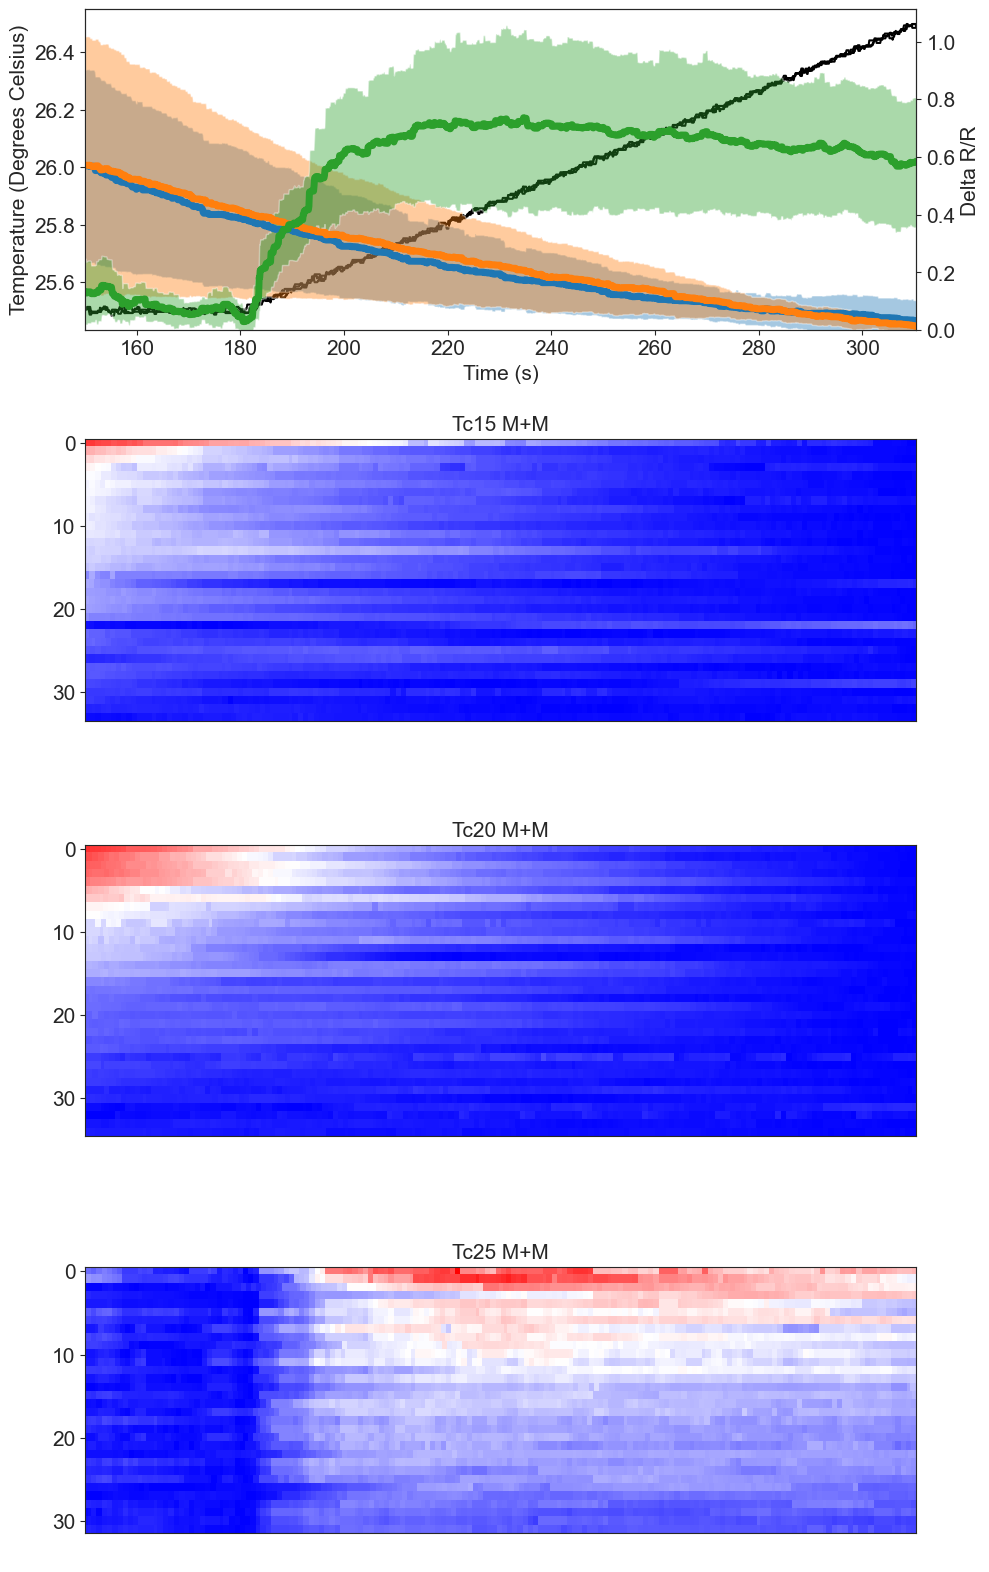

In [6]:
#conditions_plot = [ DCR3055_Tc15, DCR3055_Tc20, DCR3055_Tc25 ]
#heatmaps_plot = [ DCR3055_Tc15, DCR3055_Tc20, DCR3055_Tc25 ]
#use separate = True to separate temp stimulus from GCaMP
#plot_Delta(conditions_plot, heatmaps_plot, start_ind = 1800, legend=False)

conditions_plot = [ DCR3055_Tc15, DCR3055_Tc20, DCR3055_Tc25 ]
heatmaps_plot = [ DCR3055_Tc15, DCR3055_Tc20, DCR3055_Tc25 ]
#use separate = True to separate temp stimulus from GCaMP
plot_Delta(conditions_plot, heatmaps_plot, legend=False)


#conditions_plot = [  DCR3055_Tc25 ]
#heatmaps_plot = [  DCR3055_Tc25 ]
#use separate = True to separate temp stimulus from GCaMP
#plot_Delta(conditions_plot, heatmaps_plot, start_ind = 1800, legend=False)

# Calculating Sensitivity (Rmax/R0 @ Ramp)

Ratio Change Tc15:
 [0.99375051 0.92856347 0.92641473 0.90699393 0.92849715 0.9009246
 0.93050802 0.97973342 0.98190099 0.94829019 0.95693249 0.94163631
 1.09950064 0.96631965 0.92885546 1.00814071 1.03957894 0.88591446
 1.06381917 1.04582837 0.87267764 0.92191345 0.94275522 0.97678882
 0.90780844 0.96894976 1.00002786 0.97496294 0.87574311 0.96914642
 0.92125786 0.94237595 0.97158428 1.35551955] 

Ratio Change Tc20:
 [1.00668239 0.98242438 1.01151376 0.98275157 1.01629446 0.90640294
 0.8779483  0.90125996 0.9321604  0.925805   1.00552543 0.95289512
 0.99399373 0.97826756 0.8688373  0.89821769 1.02226554 0.95250461
 0.89118026 0.97010663 0.90516448 0.99731562 1.0826148  1.09021924
 1.00432942 1.10312655 0.90840204 1.06556923 1.01122651 0.98202898
 0.9125379  0.95343226 0.92344906 0.95573666 0.98511514] 

Ratio Change Tc25:
 [1.72217796 1.55992602 2.02385335 1.99245458 1.84301109 2.24449397
 2.09836248 1.70393176 1.78056239 1.39850868 1.48320918 1.30720467
 1.62565671 1.30120953 1.57091

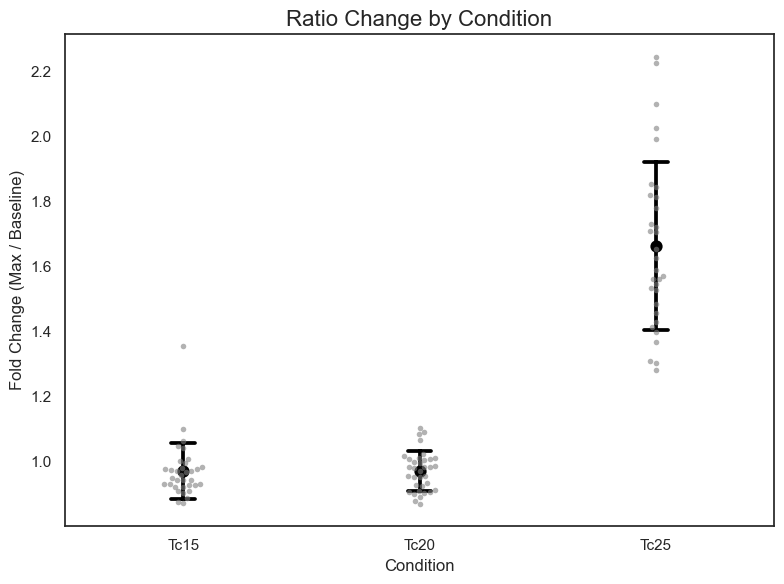

In [12]:
def calc_Ratio_Change(experiments_data):
    Ratio = experiments_data['GCaMP'] / experiments_data['RFP']
    Baseline_Ca =  np.mean( Ratio[:,0:300] , axis=1) 
    Max_Ca = np.max( Ratio[:, 300:len(experiments_data['Time'])], axis=1) 
    Ratio_change = Max_Ca / Baseline_Ca
    return Ratio_change

Tc15_Ratio_Change = calc_Ratio_Change(DCR3055_Tc15)
Tc20_Ratio_Change = calc_Ratio_Change(DCR3055_Tc20)
Tc25_Ratio_Change = calc_Ratio_Change(DCR3055_Tc25)

print( "Ratio Change Tc15:\n", Tc15_Ratio_Change, "\n" )

print( "Ratio Change Tc20:\n", Tc20_Ratio_Change, "\n" )
print( "Ratio Change Tc25:\n", Tc25_Ratio_Change, "\n" )



import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Create the Plot# Create a list of labels for each data point
conditions = (
    ['Tc15'] * len(Tc15_Ratio_Change) +
    ['Tc20'] * len(Tc20_Ratio_Change) +
    ['Tc25'] * len(Tc25_Ratio_Change)
)

# Combine all data points into one long array
values = np.concatenate([
    Tc15_Ratio_Change,
    Tc20_Ratio_Change,
    Tc25_Ratio_Change
])

# Create the DataFrame
df = pd.DataFrame({
    'Condition': conditions,
    'Fold Change': values
})

# --- 3. Create the Plot ---
sns.set_theme(style="white")
plt.figure(figsize=(8, 6))

# Plot 1: The individual data points
sns.swarmplot(
    data=df,
    x='Condition',
    y='Fold Change',
    alpha=0.6,
    color='gray',
    size=4        # Adjust size so points don't crowd the axis
)

# Plot 2: The mean and standard deviation (point plot)
# --- New, Corrected Code ---
sns.pointplot(
    data=df,
    x='Condition',
    y='Fold Change',
    linestyle='none',  # <-- Replaces join=False
    errorbar='sd',     # <-- Replaces ci='sd'
    color='black',
    capsize=0.1
)

# --- 4. Final Touches ---
plt.title('Ratio Change by Condition', fontsize=16)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Fold Change (Max / Baseline)', fontsize=12)

plt.tight_layout()
#plt.savefig("C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Q10/Ratio_Change_25C_HighStim.svg", dpi=600, bbox_inches='tight')
plt.savefig("Ratio_Change_25C_HighStim.svg", dpi=600, bbox_inches='tight')
plt.show()

In [13]:
import numpy as np
import pandas as pd
import pingouin as pg
import scikit_posthocs as sp

def _format_p_val(p_val):
    """Helper function to format p-values for display."""
    if p_val < 0.0001:
        return "< 0.0001 ****"
    elif p_val < 0.001:
        return "< 0.001 ***"
    elif p_val < 0.01:
        return "< 0.01 **"
    elif p_val < 0.05:
        return "< 0.05 *"
    else:
        return f"{p_val:.4f} ns"

def auto_compare_groups(*groups, group_names=None, alpha=0.05):
    """
    Automatically runs the correct statistical comparison test on 2 or more data groups.
    Includes assumption checks and prints post-hoc tests as a simple list.
    """
    
    # --- 1. Data Preparation ---
    if len(groups) < 2:
        raise ValueError("You must provide at least two groups to compare.")
    if group_names is None:
        group_names = [f'Group_{i+1}' for i in range(len(groups))]
    if len(groups) != len(group_names):
        raise ValueError("The number of groups and group_names must be the same.")

    conditions = []
    values = []
    for name, data in zip(group_names, groups):
        data = np.asarray(data).flatten()
        conditions.extend([name] * len(data))
        values.extend(data)
    
    df = pd.DataFrame({'Condition': conditions, 'Value': values})

    print("--- 1. Data Assumption Checks ---")

    # --- 2. Check Normality (Shapiro-Wilk) ---
    normality_results = pg.normality(df, dv='Value', group='Condition')
    all_normal = normality_results['normal'].all()
    print("Normality (Shapiro-Wilk):")
    print(normality_results.round(3))
    print(f"\nDecision: All groups appear normally distributed. ({all_normal})")

    # --- 3. Check Homogeneity of Variance (Levene) ---
    homogeneity_results = pg.homoscedasticity(df, dv='Value', group='Condition')
    are_equal_variance = homogeneity_results['equal_var'].iloc[0]
    print("\nHomogeneity of Variance (Levene):")
    print(homogeneity_results.round(3))
    print(f"\nDecision: Variances appear equal. ({are_equal_variance})")

    print("\n--- 2. Statistical Test Selection ---")
    
    stats_result = None
    # print post-hoc results directly, not return them
    posthoc_result_to_return = None 

    # --- 4. Run the Appropriate Test ---
    if len(groups) == 2:
        print("Comparing 2 groups...")
        if all_normal:
            correction = not are_equal_variance
            test_name = "Welch's t-test" if correction else "Student's t-test"
            print(f"Running {test_name}...")
            stats_result = pg.ttest(df[df['Condition'] == group_names[0]]['Value'], 
                                    df[df['Condition'] == group_names[1]]['Value'], 
                                    correction=correction)
            stats_result['p-val'] = stats_result['p-val'].apply(_format_p_val)
        else:
            print("Running Mann-Whitney U test...")
            stats_result = pg.mwu(df[df['Condition'] == group_names[0]]['Value'], 
                                  df[df['Condition'] == group_names[1]]['Value'])
            stats_result['p-val'] = stats_result['p-val'].apply(_format_p_val)
        
        print("\n--- 3. Results ---")
        return stats_result

    else: # 3 or more groups
        print(f"Comparing {len(groups)} groups...")
        if all_normal:
            if are_equal_variance:
                print("Running One-Way ANOVA...")
                stats_result = pg.anova(data=df, dv='Value', between='Condition')
                p_main = stats_result['p-val'].iloc[0]
                stats_result['p-val'] = stats_result['p-val'].apply(_format_p_val)
                
                if p_main < alpha:
                    print("\nKruskal-Wallis is significant. Running post-hoc test (Tukey's HSD)...")
                    posthoc_df = pg.pairwise_tukey(data=df, dv='Value', between='Condition')
                    
                    print("\n--- Post-Hoc Pairwise Comparisons ---")
                    for index, row in posthoc_df.iterrows():
                        print(f"  {row['A']} vs. {row['B']}: p = {_format_p_val(row['p-tukey'])}")

            else: # Not equal variance
                print("Running Welch's ANOVA (unequal variances)...")
                stats_result = pg.welch_anova(data=df, dv='Value', between='Condition')
                p_main = stats_result['p-val'].iloc[0]
                stats_result['p-val'] = stats_result['p-val'].apply(_format_p_val)

                if p_main < alpha:
                    print("\nWelch's ANOVA is significant. Running post-hoc test (Games-Howell)...")
                    posthoc_df = pg.pairwise_gameshowell(data=df, dv='Value', between='Condition')
                    
                    print("\n--- Post-Hoc Pairwise Comparisons ---")
                    for index, row in posthoc_df.iterrows():
                        print(f"  {row['A']} vs. {row['B']}: p = {_format_p_val(row['p-val'])}")
        
        else: # Not normal
            print("Running Kruskal-Wallis H-test...")
            stats_result = pg.kruskal(data=df, dv='Value', between='Condition')
            p_main = stats_result['p-unc'].iloc[0]
            stats_result['p-unc'] = stats_result['p-unc'].apply(_format_p_val)

            if p_main < alpha:
                print("\nKruskal-Wallis is significant. Running post-hoc test (Dunn's)...")
                
                matrix_result = sp.posthoc_dunn(df, val_col='Value', group_col='Condition')
                long_form = matrix_result.stack().reset_index()
                long_form.columns = ['A', 'B', 'p-unc']
                long_form = long_form[long_form['A'] != long_form['B']]
                long_form['pair'] = long_form.apply(lambda row: tuple(sorted([row['A'], row['B']])), axis=1)
                posthoc_df = long_form.drop_duplicates(subset=['pair']).drop(columns=['pair']).reset_index(drop=True)

                print("\n--- Post-Hoc Pairwise Comparisons ---")
                for index, row in posthoc_df.iterrows():
                    print(f"  {row['A']} vs. {row['B']}: p = {_format_p_val(row['p-unc'])}")

        print("\n--- 3. Results ---")
        # Returns the main test result, and None for the post-hoc part
        # because the post-hoc was printed directly.
        return stats_result, posthoc_result_to_return

In [14]:
auto_compare_groups( Tc15_Ratio_Change, Tc20_Ratio_Change, Tc25_Ratio_Change, group_names=['Tc15', 'Tc20', 'Tc25'] )

--- 1. Data Assumption Checks ---
Normality (Shapiro-Wilk):
               W   pval  normal
Condition                      
Tc15       0.732  0.000   False
Tc20       0.961  0.241    True
Tc25       0.950  0.147    True

Decision: All groups appear normally distributed. (False)

Homogeneity of Variance (Levene):
             W  pval  equal_var
levene  24.351   0.0      False

Decision: Variances appear equal. (False)

--- 2. Statistical Test Selection ---
Comparing 3 groups...
Running Kruskal-Wallis H-test...

Kruskal-Wallis is significant. Running post-hoc test (Dunn's)...

--- Post-Hoc Pairwise Comparisons ---
  Tc15 vs. Tc20: p = 0.5962 ns
  Tc15 vs. Tc25: p = < 0.0001 ****
  Tc20 vs. Tc25: p = < 0.0001 ****

--- 3. Results ---


(            Source  ddof1          H          p-unc
 Kruskal  Condition      2  64.869509  < 0.0001 ****,
 None)